In [ ]:
df = pd.read_csv('dataset/dataset.csv')

Mounted at /content/drive


In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession

In [ ]:
# MEMBUAT SPARK SESSION
spark = SparkSession.builder \
    .appName("Hotel Booking Analysis") \
    .getOrCreate()

In [ ]:
# LOAD DATASET
file_path = "/content/drive/MyDrive/MiniProject/hotel_bookings.csv"

# Load dengan pandas
df = pd.read_csv(file_path)

# Load dengan pyspark
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Menampilkan data awal
print("Ukuran dataset:", df.shape)

df.head()

Ukuran dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# INFORMASI DATASET
# Jumlah baris dan kolom
jumlah_baris = spark_df.count()
jumlah_kolom = len(spark_df.columns)

print("Jumlah baris dan kolom:")
print((jumlah_baris, jumlah_kolom))


# Informasi Dataset
print("\nInformasi dataset:")
spark_df.printSchema()

Jumlah baris dan kolom:
(119390, 32)

Informasi dataset:
root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: string (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string 

In [ ]:
# CEK MISSING VALUE
from pyspark.sql.functions import col, count, when

# Menghitung missing value tiap kolom
missing_spark = spark_df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in spark_df.columns
])

# Tampilkan hasil
missing_spark.show()

+-----+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+-------------+---+---------------------------+-------------------------+------------------+-----------------------+
|hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type|adr|required_car_parking_spaces|total_of_special_reque

In [ ]:
# CEK DUPLICATE
total_rows = spark_df.count()

unique_rows = spark_df.dropDuplicates().count()

duplicate_count = total_rows - unique_rows

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 31994


In [ ]:
# DISTRIBUSI TARGET
from pyspark.sql.functions import count

target_distribution = spark_df.groupBy("is_canceled") \
    .agg(count("*").alias("jumlah_data"))

target_distribution.show()

total_data = spark_df.count()

target_percentage = spark_df.groupBy("is_canceled") \
    .agg(
        (
            count("*") / total_data * 100
        ).alias("persentase")
    )

target_percentage.show()

+-----------+-----------+
|is_canceled|jumlah_data|
+-----------+-----------+
|          1|      44224|
|          0|      75166|
+-----------+-----------+

+-----------+------------------+
|is_canceled|        persentase|
+-----------+------------------+
|          1|37.041628277075134|
|          0|62.958371722924866|
+-----------+------------------+



In [ ]:
# ANALISIS DUPLICATE
duplicate_rows = spark_df.groupBy(spark_df.columns) \
    .count() \
    .filter("count > 1")

print("Contoh data duplicate:")

duplicate_rows.show(5, truncate=False)

Contoh data duplicate:
+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+---------------+-----+---------------------------+-------------------------+------------------+-----------------------+-----+
|hotel       |is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type  |adr  

In [ ]:
# CEK APAKAH DUPLICATE IDENTIK PENUH
shape_before = (spark_df.count(), len(spark_df.columns))

shape_after = (
    spark_df.dropDuplicates().count(),
    len(spark_df.columns)
)

print("Shape sebelum hapus duplicate :", shape_before)
print("Shape setelah hapus duplicate :", shape_after)

duplicate_percentage = (
    (shape_before[0] - shape_after[0])
    / shape_before[0]
) * 100

print(f"\nPersentase duplicate: {duplicate_percentage:.2f}%")

Shape sebelum hapus duplicate : (119390, 32)
Shape setelah hapus duplicate : (87396, 32)

Persentase duplicate: 26.80%


In [ ]:
# SELECT FITUR DENGAN PYSPARK
selected_columns = [
    'is_canceled',
    'lead_time',
    'adr',
    'hotel',
    'arrival_date_month',
    'customer_type',
    'deposit_type',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',
    'market_segment'
]

spark_selected = spark_df.select(selected_columns)

print("Jumlah data sebelum drop duplicate:")
print(spark_selected.count())

spark_selected = spark_selected.dropDuplicates()

print("\nJumlah data setelah drop duplicate:")
print(spark_selected.count())

Jumlah data sebelum drop duplicate:
119390

Jumlah data setelah drop duplicate:
79246


In [ ]:
# HAPUS DUPLICATE
spark_selected = spark_selected.dropDuplicates()

print("\nJumlah data setelah drop duplicate:")
print(spark_selected.count())


Jumlah data setelah drop duplicate:
79246


In [ ]:
# CEK MISSING VALUE PADA FITUR FINAL
from pyspark.sql.functions import col, count, when

missing_values = spark_selected.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in spark_selected.columns
])

missing_values.show()

+-----------+---------+---+-----+------------------+-------------+------------+----------------------+---------------+-------------------------+--------------+
|is_canceled|lead_time|adr|hotel|arrival_date_month|customer_type|deposit_type|previous_cancellations|booking_changes|total_of_special_requests|market_segment|
+-----------+---------+---+-----+------------------+-------------+------------+----------------------+---------------+-------------------------+--------------+
|          0|        0|  0|    0|                 0|            0|           0|                     0|              0|                        0|             0|
+-----------+---------+---+-----+------------------+-------------+------------+----------------------+---------------+-------------------------+--------------+



In [ ]:
# CEK TIPE DATA
spark_selected.printSchema()

root
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- adr: double (nullable = true)
 |-- hotel: string (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- customer_type: string (nullable = true)
 |-- deposit_type: string (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- booking_changes: integer (nullable = true)
 |-- total_of_special_requests: integer (nullable = true)
 |-- market_segment: string (nullable = true)



In [ ]:
# CONVERT KE PANDAS
df_clean = spark_selected.toPandas()

print(df_clean.shape)

df_clean.head()

(79246, 11)


,is_canceled,lead_time,adr,hotel,arrival_date_month,customer_type,deposit_type,previous_cancellations,booking_changes,total_of_special_requests,market_segment
0,1,72,73.80,Resort Hotel,July,Transient,No Deposit,0,0,1,Online TA
1,0,68,124.00,Resort Hotel,July,Transient,No Deposit,0,0,1,Direct
2,0,31,161.00,Resort Hotel,July,Transient,No Deposit,0,1,1,Direct
3,0,13,58.24,Resort Hotel,October,Transient,No Deposit,0,0,0,Offline TA/TO
4,0,130,98.40,Resort Hotel,October,Transient,No Deposit,0,0,0,Online TA


In [ ]:
def add_bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f')

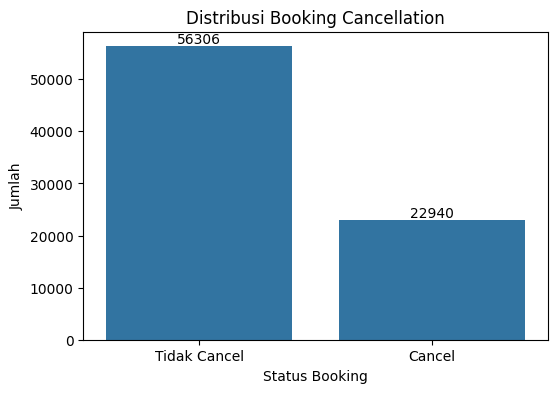

In [ ]:
# DISTRIBUSI TARGET
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df_clean,
    x='is_canceled'
)

add_bar_labels(ax)

plt.title('Distribusi Booking Cancellation')
plt.xlabel('Status Booking')
plt.ylabel('Jumlah')

plt.xticks(
    [0, 1],
    ['Tidak Cancel', 'Cancel']
)

plt.show()

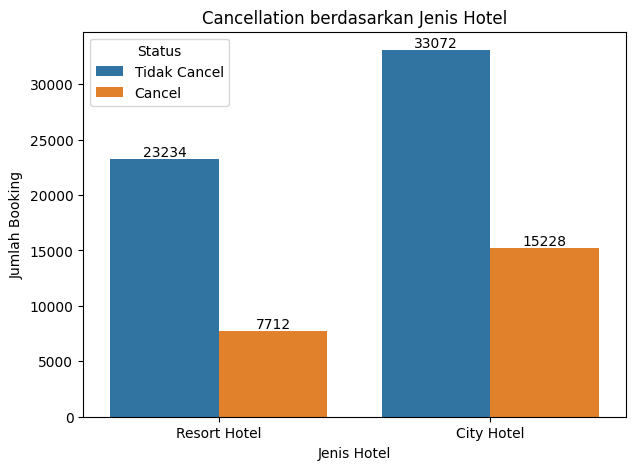

In [ ]:
# CANCELLATION BERDASARKAN HOTEL
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df_clean,
    x='hotel',
    hue='is_canceled'
)

add_bar_labels(ax)

plt.title('Cancellation berdasarkan Jenis Hotel')
plt.xlabel('Jenis Hotel')
plt.ylabel('Jumlah Booking')

plt.legend(
    title='Status',
    labels=['Tidak Cancel', 'Cancel']
)

plt.show()

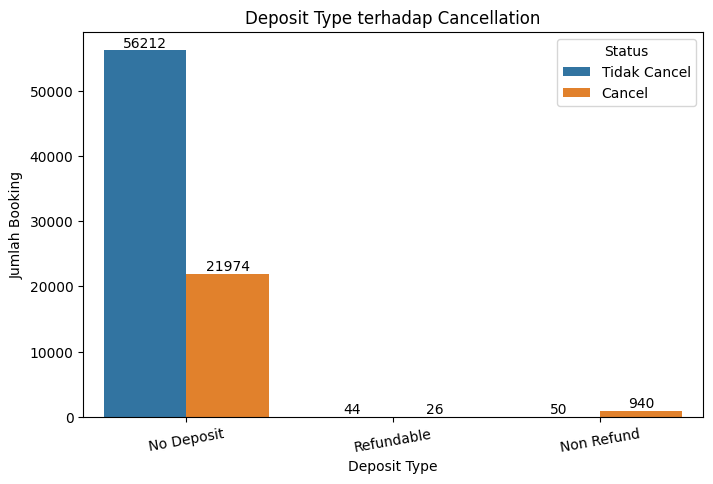

In [ ]:
# DEPOSIT TYPE VS CANCELLATION
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x='deposit_type',
    hue='is_canceled'
)

add_bar_labels(ax)

plt.title('Deposit Type terhadap Cancellation')
plt.xlabel('Deposit Type')
plt.ylabel('Jumlah Booking')

plt.legend(
    title='Status',
    labels=['Tidak Cancel', 'Cancel']
)

plt.xticks(rotation=10)

plt.show()

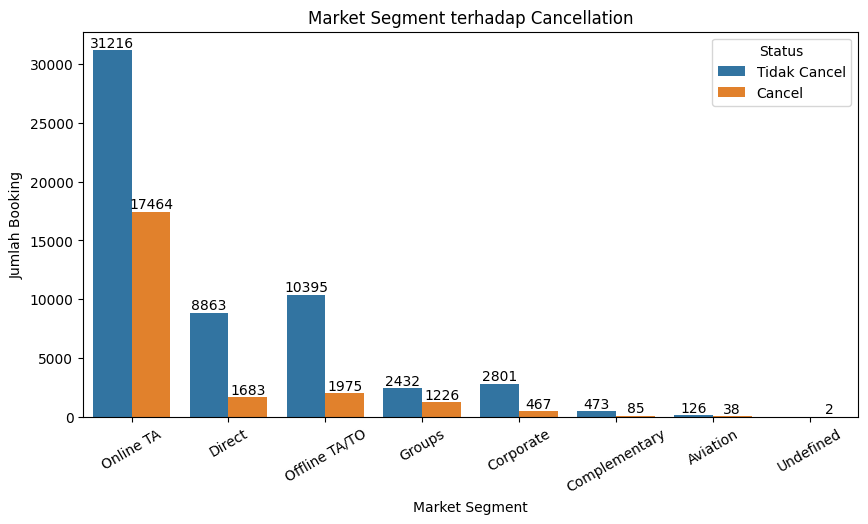

In [ ]:
# MARKET SEGMENT VS CANCELLATION
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_clean,
    x='market_segment',
    hue='is_canceled'
)

add_bar_labels(ax)

plt.title('Market Segment terhadap Cancellation')
plt.xlabel('Market Segment')
plt.ylabel('Jumlah Booking')

plt.legend(
    title='Status',
    labels=['Tidak Cancel', 'Cancel']
)

plt.xticks(rotation=30)

plt.show()

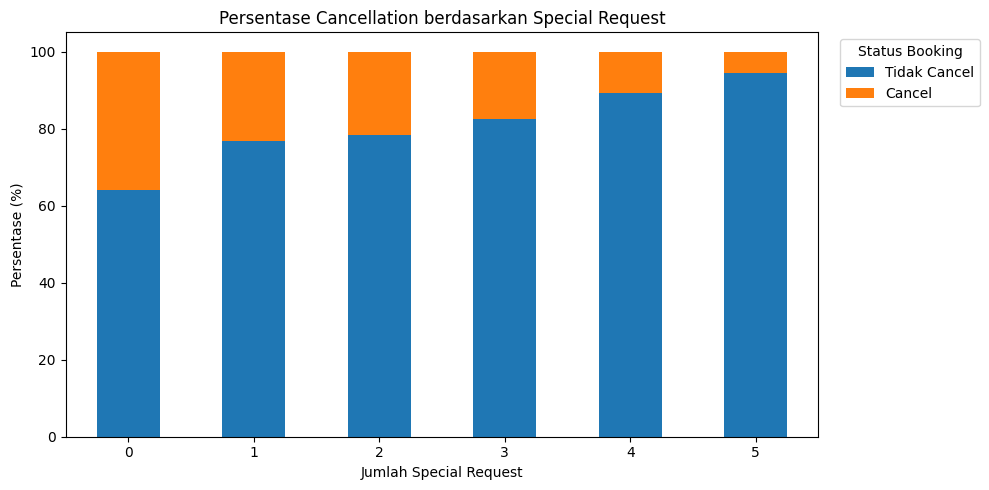

In [ ]:
# CANCELLATION RATE BERDASARKAN SPECIAL REQUEST

special_request_ct = pd.crosstab(
    df_clean['total_of_special_requests'],
    df_clean['is_canceled'],
    normalize='index'
) * 100

ax = special_request_ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title('Persentase Cancellation berdasarkan Special Request')
plt.xlabel('Jumlah Special Request')
plt.ylabel('Persentase (%)')

plt.xticks(rotation=0)

plt.legend(
    ['Tidak Cancel', 'Cancel'],
    title='Status Booking',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [ ]:
# STATISTIK DESKRIPTIF
df_clean.describe()

,is_canceled,lead_time,adr,previous_cancellations,booking_changes,total_of_special_requests
count,79246.000000,79246.000000,79246.000000,79246.000000,79246.000000,79246.000000
mean,0.289478,81.508291,108.623014,0.032431,0.279850,0.730371
std,0.453523,85.295833,55.679474,0.384911,0.745388,0.842689
min,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000
25%,0.000000,13.000000,74.500000,0.000000,0.000000,0.000000
50%,0.000000,52.000000,100.000000,0.000000,0.000000,1.000000
75%,1.000000,127.000000,136.000000,0.000000,0.000000,1.000000
max,1.000000,737.000000,5400.000000,26.000000,21.000000,5.000000


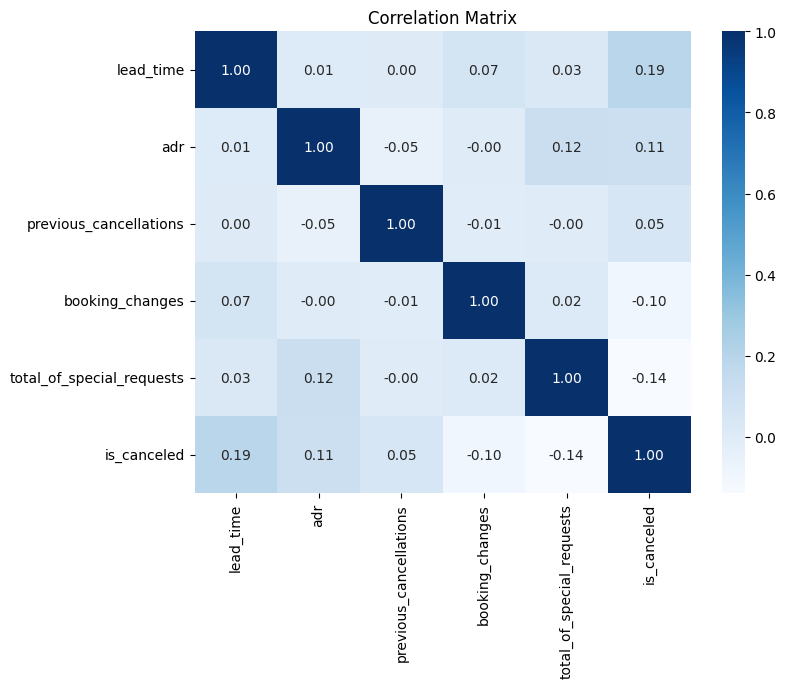

In [ ]:
# KORELASI FITUR NUMERIK
numeric_columns = [
    'lead_time',
    'adr',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',
    'is_canceled'
]

correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

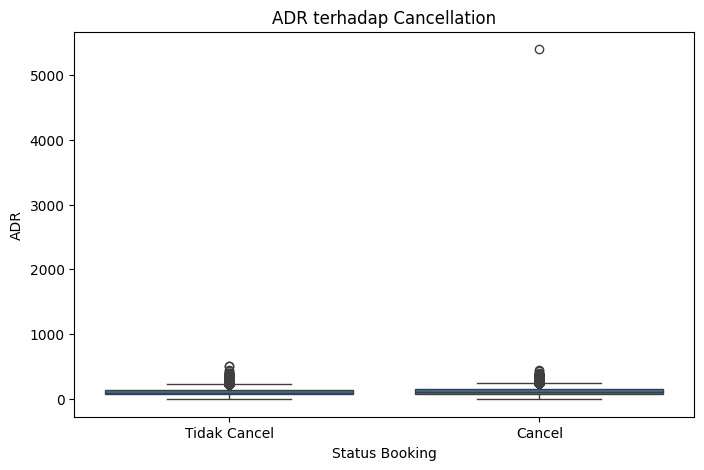

In [ ]:
# ADR VS CANCELLATION
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='is_canceled',
    y='adr'
)

plt.title('ADR terhadap Cancellation')
plt.xlabel('Status Booking')
plt.ylabel('ADR')

plt.xticks(
    [0,1],
    ['Tidak Cancel', 'Cancel']
)

plt.show()

In [ ]:
# IMPORT LIBRARY PYSPARK ML
from pyspark.ml.feature import (
    StringIndexer,
    VectorAssembler
)

from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)

from pyspark.ml import Pipeline

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

In [ ]:
# ENCODING FITUR KATEGORIKAL
categorical_columns = [
    'hotel',
    'arrival_date_month',
    'customer_type',
    'deposit_type',
    'market_segment'
]

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_indexed",
        handleInvalid="keep"
    )
    for col in categorical_columns
]

In [ ]:
# MENYIAPKAN FITUR MODEL
feature_columns = [
    'lead_time',
    'adr',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',

    'hotel_indexed',
    'arrival_date_month_indexed',
    'customer_type_indexed',
    'deposit_type_indexed',
    'market_segment_indexed'
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol='features'
)

In [ ]:
# MEMBUAT PIPELINE
pipeline = Pipeline(
    stages=indexers + [assembler]
)

pipeline_model = pipeline.fit(spark_selected)

processed_data = pipeline_model.transform(spark_selected)

processed_data.select(
    'features',
    'is_canceled'
).show(5, truncate=False)

+--------------------------------------------+-----------+
|features                                    |is_canceled|
+--------------------------------------------+-----------+
|(10,[0,1,4,5,6],[72.0,73.8,1.0,1.0,1.0])    |1          |
|[68.0,124.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0]|0          |
|[31.0,161.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0]|0          |
|(10,[0,1,5,6,9],[13.0,58.24,1.0,6.0,1.0])   |0          |
|(10,[0,1,5,6],[130.0,98.4,1.0,6.0])         |0          |
+--------------------------------------------+-----------+
only showing top 5 rows


In [ ]:
# TRAIN TEST SPLIT
train_data, test_data = processed_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Jumlah data train:", train_data.count())
print("Jumlah data test :", test_data.count())

Jumlah data train: 63508
Jumlah data test : 15738


In [ ]:
# LOGISTIC REGRESSION
lr = LogisticRegression(
    featuresCol='features',
    labelCol='is_canceled'
)

# Training model
lr_model = lr.fit(train_data)

# Prediksi
lr_predictions = lr_model.transform(test_data)

# Menampilkan hasil prediksi
lr_predictions.select(
    'is_canceled',
    'prediction',
    'probability'
).show(5, truncate=False)

+-----------+----------+------------------------------------------+
|is_canceled|prediction|probability                               |
+-----------+----------+------------------------------------------+
|0          |0.0       |[0.9307924563055888,0.06920754369441118]  |
|0          |0.0       |[0.9482770618013234,0.05172293819867657]  |
|0          |0.0       |[0.8912105059574698,0.10878949404253024]  |
|0          |0.0       |[0.9997657959333793,2.3420406662066906E-4]|
|0          |0.0       |[0.8548383907011632,0.1451616092988368]   |
+-----------+----------+------------------------------------------+
only showing top 5 rows


In [ ]:
# EVALUASI LOGISTIC REGRESSION
# Accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol='is_canceled',
    predictionCol='prediction',
    metricName='accuracy'
)

lr_accuracy = accuracy_evaluator.evaluate(lr_predictions)

# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol='is_canceled',
    predictionCol='prediction',
    metricName='f1'
)

lr_f1 = f1_evaluator.evaluate(lr_predictions)

# ROC AUC
auc_evaluator = BinaryClassificationEvaluator(
    labelCol='is_canceled',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

lr_auc = auc_evaluator.evaluate(lr_predictions)

# Print hasil
print("=== Logistic Regression ===")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC AUC  : {lr_auc:.4f}")

=== Logistic Regression ===
Accuracy : 0.7509
F1 Score : 0.7080
ROC AUC  : 0.7417


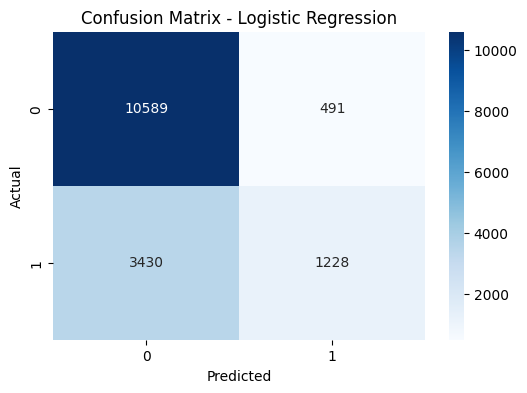

In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

# Convert ke pandas
lr_pred_pd = lr_predictions.select(
    'is_canceled',
    'prediction'
).toPandas()

cm = confusion_matrix(
    lr_pred_pd['is_canceled'],
    lr_pred_pd['prediction']
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
# RANDOM FOREST
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='is_canceled',
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Training model
rf_model = rf.fit(train_data)

# Prediksi
rf_predictions = rf_model.transform(test_data)

# Menampilkan hasil prediksi
rf_predictions.select(
    'is_canceled',
    'prediction',
    'probability'
).show(5, truncate=False)

+-----------+----------+----------------------------------------+
|is_canceled|prediction|probability                             |
+-----------+----------+----------------------------------------+
|0          |0.0       |[0.927172059515968,0.0728279404840319]  |
|0          |0.0       |[0.9245531933162597,0.07544680668374026]|
|0          |0.0       |[0.8264709942495544,0.1735290057504455] |
|0          |0.0       |[0.9337982352325571,0.06620176476744297]|
|0          |0.0       |[0.9524276107605761,0.04757238923942387]|
+-----------+----------+----------------------------------------+
only showing top 5 rows


In [ ]:
# EVALUASI RANDOM FOREST
# Accuracy
rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)

# F1 Score
rf_f1 = f1_evaluator.evaluate(rf_predictions)

# ROC AUC
rf_auc = auc_evaluator.evaluate(rf_predictions)

# Print hasil
print("=== Random Forest ===")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

=== Random Forest ===
Accuracy : 0.7842
F1 Score : 0.7683
ROC AUC  : 0.8004


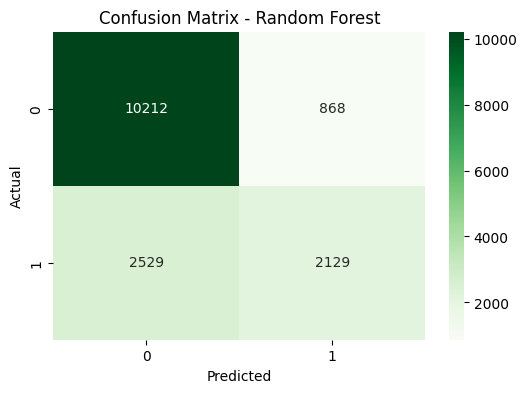

In [ ]:
# CONFUSION MATRIX RANDOM FOREST
# Convert ke pandas
rf_pred_pd = rf_predictions.select(
    'is_canceled',
    'prediction'
).toPandas()

cm_rf = confusion_matrix(
    rf_pred_pd['is_canceled'],
    rf_pred_pd['prediction']
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
# PERBANDINGAN MODEL
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        rf_accuracy
    ],
    'F1 Score': [
        lr_f1,
        rf_f1
    ],
    'ROC AUC': [
        lr_auc,
        rf_auc
    ]
})

comparison_df

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.750858,0.708033,0.741744
1,Random Forest,0.784153,0.768261,0.800439


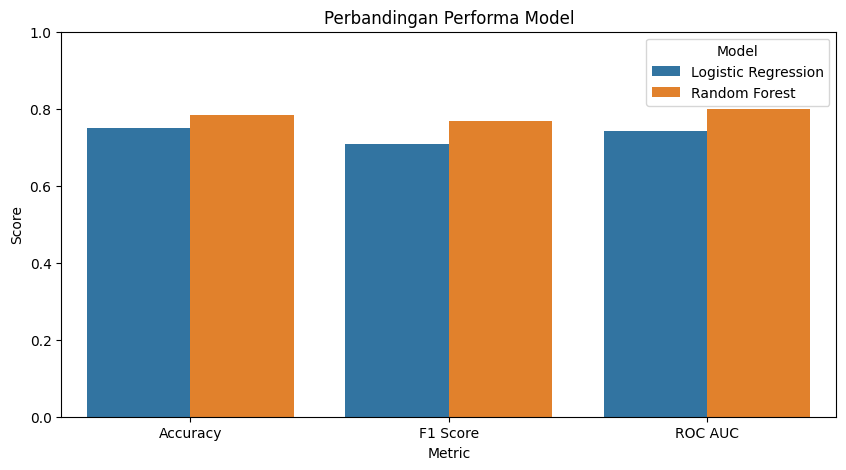

In [ ]:
# VISUALISASI PERBANDINGAN MODEL
comparison_melted = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model'
)


plt.ylim(0,1)

plt.title('Perbandingan Performa Model')

plt.show()

In [ ]:
# FEATURE IMPORTANCE
importance = rf_model.featureImportances

feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importance.toArray()
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
0,lead_time,0.228234
9,market_segment_indexed,0.194735
4,total_of_special_requests,0.190071
8,deposit_type_indexed,0.105761
2,previous_cancellations,0.082005
7,customer_type_indexed,0.059062
3,booking_changes,0.051391
1,adr,0.047466
6,arrival_date_month_indexed,0.030803
5,hotel_indexed,0.010472


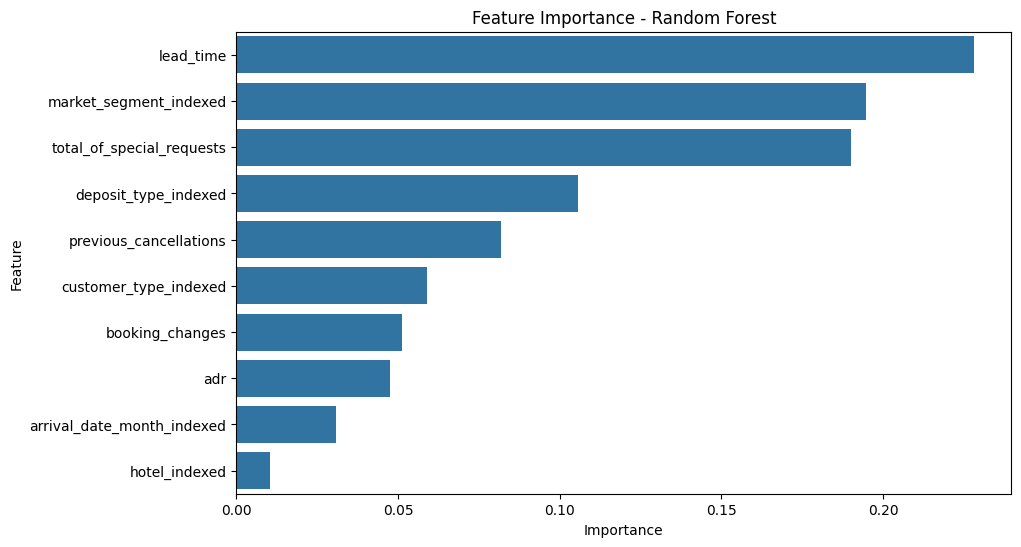

In [ ]:
# VISUALISASI FEATURE IMPORTANCE
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')

plt.show()

In [ ]:
# SIMULASI
sample_customers = spark.createDataFrame([

    # CUSTOMER 1
    (
        120,               # lead_time
        150.0,             # adr
        1,                 # previous_cancellations
        0,                 # booking_changes
        0,                 # total_of_special_requests
        'City Hotel',
        'August',
        'Transient',
        'No Deposit',
        'Online TA'
    ),

    # CUSTOMER 2
  (
    2,
    50.0,
    0,
    5,
    5,
    'Resort Hotel',
    'January',
    'Transient-Party',
    'Non Refund',
    'Direct'
)

], [
    'lead_time',
    'adr',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',
    'hotel',
    'arrival_date_month',
    'customer_type',
    'deposit_type',
    'market_segment'
])

sample_customers.show(truncate=False)

+---------+-----+----------------------+---------------+-------------------------+------------+------------------+---------------+------------+--------------+
|lead_time|adr  |previous_cancellations|booking_changes|total_of_special_requests|hotel       |arrival_date_month|customer_type  |deposit_type|market_segment|
+---------+-----+----------------------+---------------+-------------------------+------------+------------------+---------------+------------+--------------+
|120      |150.0|1                     |0              |0                        |City Hotel  |August            |Transient      |No Deposit  |Online TA     |
|2        |50.0 |0                     |5              |5                        |Resort Hotel|January           |Transient-Party|Non Refund  |Direct        |
+---------+-----+----------------------+---------------+-------------------------+------------+------------------+---------------+------------+--------------+



In [ ]:
# PREPROCESSING & PREDIKSI
sample_processed = pipeline_model.transform(sample_customers)

sample_predictions = rf_model.transform(sample_processed)

sample_predictions.select(
    'hotel',
    'lead_time',
    'deposit_type',
    'market_segment',
    'prediction',
    'probability'
).show(truncate=False)

+------------+---------+------------+--------------+----------+---------------------------------------+
|hotel       |lead_time|deposit_type|market_segment|prediction|probability                            |
+------------+---------+------------+--------------+----------+---------------------------------------+
|City Hotel  |120      |No Deposit  |Online TA     |1.0       |[0.179195629893771,0.820804370106229]  |
|Resort Hotel|2        |Non Refund  |Direct        |0.0       |[0.8712826000943652,0.1287173999056348]|
+------------+---------+------------+--------------+----------+---------------------------------------+



Pelanggan pertama diprediksi akan melakukan pembatalan booking dengan probabilitas sebesar 82.08%, sedangkan kemungkinan tidak cancel hanya sekitar 17.92%. Hal ini dipengaruhi oleh beberapa faktor utama, yaitu pelanggan melakukan booking sangat jauh hari sebelum check-in (lead_time = 120), menggunakan tipe pembayaran No Deposit, serta berasal dari market segment Online TA. Berdasarkan hasil analisis sebelumnya, kombinasi karakteristik tersebut memang memiliki tingkat cancellation yang tinggi pada data historis. Oleh karena itu, model Random Forest mengklasifikasikan pelanggan ini sebagai pelanggan dengan risiko pembatalan yang tinggi.   
   
---

Pelanggan kedua diprediksi tidak akan melakukan pembatalan booking dengan probabilitas sebesar 87.13%, sedangkan kemungkinan cancel hanya sekitar 12.87%. Prediksi ini dipengaruhi oleh beberapa faktor yang menunjukkan perilaku pelanggan yang lebih stabil, seperti lead_time yang sangat pendek (2 hari), penggunaan tipe pembayaran Non Refund, serta market segment Direct. Kombinasi tersebut menunjukkan bahwa pelanggan memiliki komitmen reservasi yang lebih kuat sehingga risiko pembatalan menjadi jauh lebih rendah. Oleh karena itu, model mengklasifikasikan pelanggan ini sebagai pelanggan dengan kemungkinan besar tetap melanjutkan reservasi hotel.

### 1. Lead Time Menjadi Faktor Paling Berpengaruh

Hasil feature importance menunjukkan bahwa lead_time merupakan faktor paling dominan dalam memengaruhi cancellation booking. Pelanggan yang melakukan reservasi jauh hari sebelum tanggal check-in cenderung memiliki kemungkinan lebih tinggi untuk membatalkan booking. Hal ini disebabkan karena pelanggan masih memiliki banyak waktu untuk mengubah rencana perjalanan, menemukan alternatif hotel lain, atau membatalkan perjalanan secara keseluruhan.

Implikasi Bisnis:
* Hotel dapat menerapkan reminder otomatis menjelang check-in.
* Booking dengan lead time tinggi dapat dikenakan deposit tambahan.
* Hotel dapat memberikan promo khusus untuk early booking agar pelanggan lebih berkomitmen.

### 2. Market Segment Sangat Memengaruhi Tingkat Cancellation

Pelanggan dari segment Online TA memiliki tingkat cancellation yang lebih tinggi dibanding segment lainnya seperti Direct atau Corporate. Hal ini menunjukkan bahwa pelanggan dari platform OTA cenderung lebih fleksibel dalam melakukan pembatalan reservasi.

Implikasi Bisnis:
* Hotel perlu mengevaluasi strategi penjualan melalui OTA.
* Direct booking perlu lebih ditingkatkan melalui promo atau membership.
* Hotel dapat memberikan benefit tambahan untuk pelanggan yang booking langsung melalui website resmi.

### 3. Kebijakan Deposit Efektif Mengurangi Cancellation

Booking dengan tipe Non Refund memiliki kemungkinan cancellation yang jauh lebih rendah dibanding No Deposit. Hal ini menunjukkan bahwa kebijakan pembayaran memiliki pengaruh besar terhadap komitmen pelanggan.

Implikasi Bisnis:
* Hotel dapat menerapkan kebijakan deposit bertingkat.
* Opsi non-refundable booking dapat diberikan dengan harga lebih murah.
* Sistem pembayaran dapat dimanfaatkan sebagai strategi pengurangan cancellation.

### 4. Pelanggan dengan Banyak Special Request Cenderung Tidak Cancel

Pelanggan yang memberikan banyak special request terbukti memiliki tingkat cancellation yang lebih rendah. Hal ini menunjukkan bahwa pelanggan tersebut lebih serius terhadap reservasi yang dilakukan.

Implikasi Bisnis:
* Hotel dapat meningkatkan personalisasi layanan pelanggan.
* Sistem reservasi dapat mendorong pelanggan untuk mengisi preferensi atau special request.
* Personalisasi layanan dapat meningkatkan loyalitas pelanggan.

### 5. Riwayat Cancellation Menjadi Indikator Risiko

Pelanggan yang pernah melakukan cancellation sebelumnya memiliki kecenderungan lebih tinggi untuk membatalkan booking kembali.

Implikasi Bisnis:
* Hotel dapat menerapkan customer risk scoring.
* Pelanggan dengan histori cancellation tinggi dapat dikenakan kebijakan pembayaran berbeda.
* Sistem prediksi dapat digunakan untuk mendeteksi booking berisiko tinggi sejak awal.

### Kesimpulan

Penelitian ini berhasil melakukan analisis terhadap faktor-faktor yang memengaruhi pembatalan booking hotel menggunakan dataset Hotel Booking Demand dari Kaggle. Proses analisis dilakukan menggunakan pendekatan Big Data dan Machine Learning dengan bantuan PySpark untuk pengolahan data serta Random Forest dan Logistic Regression untuk pemodelan prediksi.     


Hasil analisis menunjukkan bahwa beberapa faktor utama yang memengaruhi cancellation booking adalah `lead_time`, `market_segment`,` deposit_type`, `total_of_special_requests`, dan` previous_cancellations`.   


Berdasarkan hasil evaluasi model, Random Forest memberikan performa terbaik dibanding Logistic Regression dengan nilai:

* Accuracy sebesar 78.42%
* F1 Score sebesar 76.83%
* ROC AUC sebesar 80.04%

Hasil tersebut menunjukkan bahwa model Random Forest cukup baik dalam memprediksi kemungkinan pembatalan booking hotel. Selain itu, model juga berhasil digunakan untuk melakukan simulasi prediksi pelanggan baru.